In [64]:
import pandas as pd
import numpy as np

In [65]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [66]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [67]:
df.dropna(inplace=True)

In [68]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
885,0,39.0,29.1250
886,0,27.0,13.0000
887,1,19.0,30.0000
889,1,26.0,30.0000


In [69]:
df.shape

(714, 3)

In [70]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [71]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [72]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [73]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [74]:

clf = DecisionTreeClassifier()

In [75]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [76]:

accuracy_score(y_test,y_pred)

0.6363636363636364

In [77]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6316705790297339)

In [78]:
kbin_age = KBinsDiscretizer(n_bins=20,encode='onehot',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=20,encode='ordinal',strategy='quantile')

In [79]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [80]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

c:\Users\Garv\Desktop\ml nbs\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Garv\Desktop\ml nbs\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [81]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  4.  , 14.  , 18.  , 19.  , 21.  , 22.  , 24.  , 25.  ,
              27.  , 28.5 , 30.  , 32.  , 34.  , 36.  , 39.  , 42.  , 45.5 ,
              50.  , 57.5 , 80.  ])                                         ],
      dtype=object)

In [82]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.     ,   7.2292 ,   7.75   ,   7.8542 ,   7.8958 ,   8.05   ,
                9.225  ,  10.5    ,  13.     ,  13.45835,  15.75   ,  20.23125,
               26.     ,  26.41875,  29.125  ,  34.375  ,  51.4792 ,  67.95   ,
               82.1708 , 134.075  , 512.3292 ])                                ],
      dtype=object)

In [83]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [84]:
# pd.cut used to bin continuous numerical data into discrete intervals
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())



In [85]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
708,22.0,<Compressed Sparse Row sparse matrix of dtype ...,151.5500,<Compressed Sparse Row sparse matrix of dtype ...,"(21.0, 22.0]","(134.075, 512.329]"
581,39.0,<Compressed Sparse Row sparse matrix of dtype ...,110.8833,<Compressed Sparse Row sparse matrix of dtype ...,"(36.0, 39.0]","(82.171, 134.075]"
725,20.0,<Compressed Sparse Row sparse matrix of dtype ...,8.6625,<Compressed Sparse Row sparse matrix of dtype ...,"(19.0, 21.0]","(8.05, 9.225]"
693,25.0,<Compressed Sparse Row sparse matrix of dtype ...,7.2250,<Compressed Sparse Row sparse matrix of dtype ...,"(24.0, 25.0]","(0.0, 7.229]"
702,18.0,<Compressed Sparse Row sparse matrix of dtype ...,14.4542,<Compressed Sparse Row sparse matrix of dtype ...,"(14.0, 18.0]","(13.458, 15.75]"


In [86]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [87]:
accuracy_score(y_test,y_pred2)

0.6083916083916084

In [88]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

c:\Users\Garv\Desktop\ml nbs\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Garv\Desktop\ml nbs\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Garv\Desktop\ml nbs\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., 

np.float64(0.6260758998435054)

In [89]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()
    

0.6331181533646322


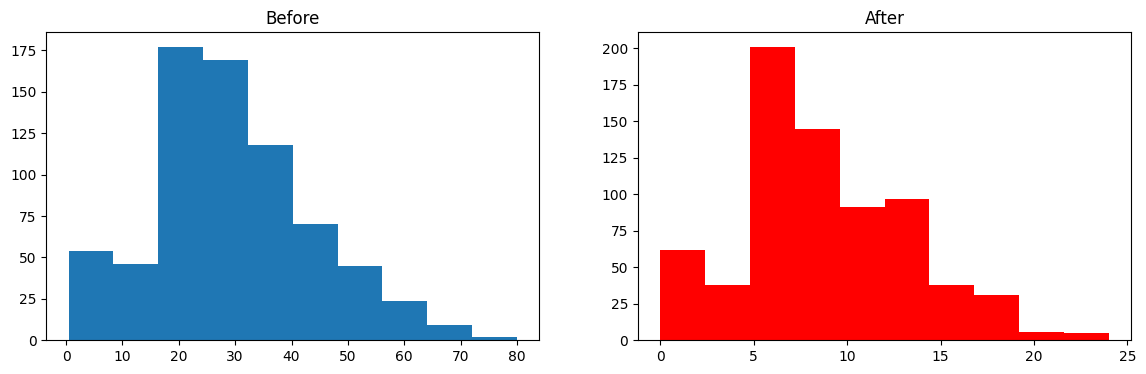

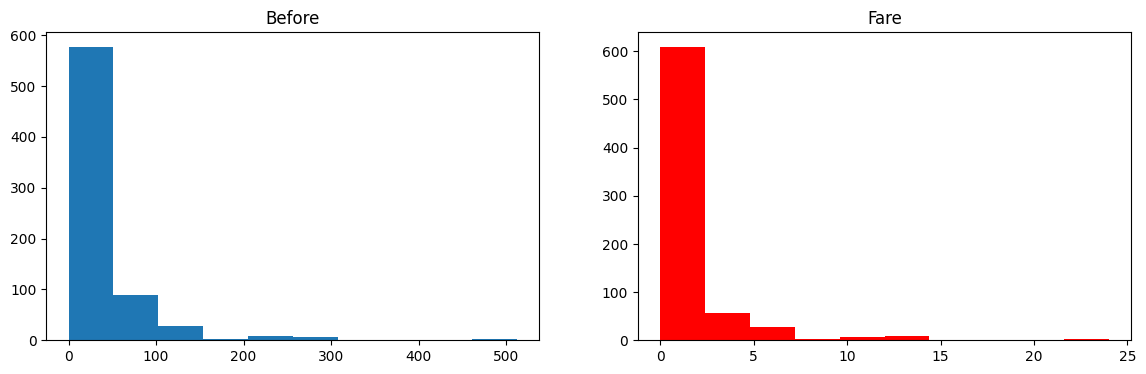

In [90]:
discretize(25,'uniform')

In [91]:
help(KBinsDiscretizer)

Help on class KBinsDiscretizer in module sklearn.preprocessing._discretization:

class KBinsDiscretizer(sklearn.base.TransformerMixin, sklearn.base.BaseEstimator)
 |  KBinsDiscretizer(
 |      n_bins=5,
 |      *,
 |      encode='onehot',
 |      strategy='quantile',
 |      quantile_method='warn',
 |      dtype=None,
 |      subsample=200000,
 |      random_state=None
 |  )
 |
 |  Bin continuous data into intervals.
 |
 |  Read more in the :ref:`User Guide <preprocessing_discretization>`.
 |
 |  .. versionadded:: 0.20
 |
 |  Parameters
 |  ----------
 |  n_bins : int or array-like of shape (n_features,), default=5
 |      The number of bins to produce. Raises ValueError if ``n_bins < 2``.
 |
 |  encode : {'onehot', 'onehot-dense', 'ordinal'}, default='onehot'
 |      Method used to encode the transformed result.
 |
 |      - 'onehot': Encode the transformed result with one-hot encoding
 |        and return a sparse matrix. Ignored features are always
 |        stacked to the right.
 |